# **Forcasting Demand for Inventory Product**

**Business Problem** : 
- Fluctuating demand Patterns leading excessive inventory level or stockouts
- High Carring Cost with Maintaining excess inventory impacting profitablity
- Inacurate inventory management
- Inefficency supply chain

**Goal**

- Optimize Inventory levels
- Sales and Marketing Strategies
- Seasonal and cyclical trends
- Customer service and satisfaction

In [1]:
!pip install prophet

## 1. Import necessaries libreries

In [2]:
import numpy as np # librery for numerical pyton
import pandas as pd # Librery for data manipulation
import seaborn as sns # Librery for visualization
import matplotlib.pyplot as plt #  Librery for visualization


## 2. Load the data

In [3]:
# Load Historical Demand data
data_demand = pd.read_csv('Historical Demand Data.csv')

In [4]:
# Load Historical Product Demand
data_Product = pd.read_csv('Historical Product Demand.csv')

In [5]:
# Load Inventory dataset
data_inventory = pd.read_csv('inventory_dataset.csv')


#### 2.1 Let Visualize the dataset

In [6]:
# Let Visualize the demand dataset
data_demand.head()

,Date,Product_id,Demand
0,2012-01-01,Product_001,3
1,2012-01-01,Product_002,1
2,2012-01-01,Product_003,3
3,2012-01-01,Product_004,3
4,2012-01-01,Product_005,7


In [7]:
# Let visualize the demand datatype
data_demand.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9140 entries, 0 to 9139
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Date        9140 non-null   object
 1   Product_id  9140 non-null   object
 2   Demand      9140 non-null   int64 
dtypes: int64(1), object(2)
memory usage: 214.3+ KB


In [8]:
# Let Visualize Product demand
data_Product.head()

,Product_Code,Warehouse,Product_Category,Date,Order_Demand
0,Product_0993,Whse_J,Category_028,2012-07-27,100
1,Product_0979,Whse_J,Category_028,2012-01-19,500
2,Product_0979,Whse_J,Category_028,2012-02-03,500
3,Product_0979,Whse_J,Category_028,2012-02-09,500
4,Product_0979,Whse_J,Category_028,2012-03-02,500


In [9]:
# Let visualize the demand datatype
data_Product.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   Product_Code      1048575 non-null  object
 1   Warehouse         1048575 non-null  object
 2   Product_Category  1048575 non-null  object
 3   Date              1037336 non-null  object
 4   Order_Demand      1048575 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 40.0+ MB


In [10]:
# Let Visualize Inventory dataset
data_inventory.head()

,Date,Product_ID,Demand,Seasonality,Lead_Time_Days
0,2021-01-30,13,66.378698,Spring,25
1,2018-08-17,89,44.821924,Winter,17
2,2021-07-01,69,23.610530,Spring,4
3,2021-03-14,34,47.615425,Fall,26
4,2022-07-05,56,72.192019,Winter,28


In [11]:
# Let Visualize Inventory datatype
data_inventory.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Date            10000 non-null  object 
 1   Product_ID      10000 non-null  int64  
 2   Demand          10000 non-null  float64
 3   Seasonality     10000 non-null  object 
 4   Lead_Time_Days  10000 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 390.8+ KB


In [12]:
# Let check a missing date

datasets = {
    "data_demand": data_demand,
    "data_Product": data_Product,
    "data_inventory": data_inventory
}

for name, df in datasets.items():
    print(f"\n🔎 Missing values in {name}")
    print(df.isnull().sum())


🔎 Missing values in data_demand
Date          0
Product_id    0
Demand        0
dtype: int64

🔎 Missing values in data_Product
Product_Code            0
Warehouse               0
Product_Category        0
Date                11239
Order_Demand            0
dtype: int64

🔎 Missing values in data_inventory
Date              0
Product_ID        0
Demand            0
Seasonality       0
Lead_Time_Days    0
dtype: int64


In [13]:
for name, df in datasets.items():
    print(f"\n🔎 {name} missing %")
    print((df.isnull().mean() * 100).round(2))


🔎 data_demand missing %
Date          0.0
Product_id    0.0
Demand        0.0
dtype: float64

🔎 data_Product missing %
Product_Code        0.00
Warehouse           0.00
Product_Category    0.00
Date                1.07
Order_Demand        0.00
dtype: float64

🔎 data_inventory missing %
Date              0.0
Product_ID        0.0
Demand            0.0
Seasonality       0.0
Lead_Time_Days    0.0
dtype: float64


In [14]:
# Let drop the column date on data_product, because of massive missing values (11,239) and can increase overfiting
data_Product = data_Product.drop(columns=['Date'])

In [15]:
# Let confirm the missing value
data_Product.isnull().sum()

Product_Code        0
Warehouse           0
Product_Category    0
Order_Demand        0
dtype: int64

### Observation 

## Exploratory data analysis

we will explore more Demand and also do a visualization
visualize each year

In [16]:
# Principal statistic descriptive 

data_demand.describe()

,Demand
count,9140.000000
mean,17.673961
std,9.796141
min,0.000000
25%,10.000000
50%,16.000000
75%,24.000000
max,65.000000


<Axes: >

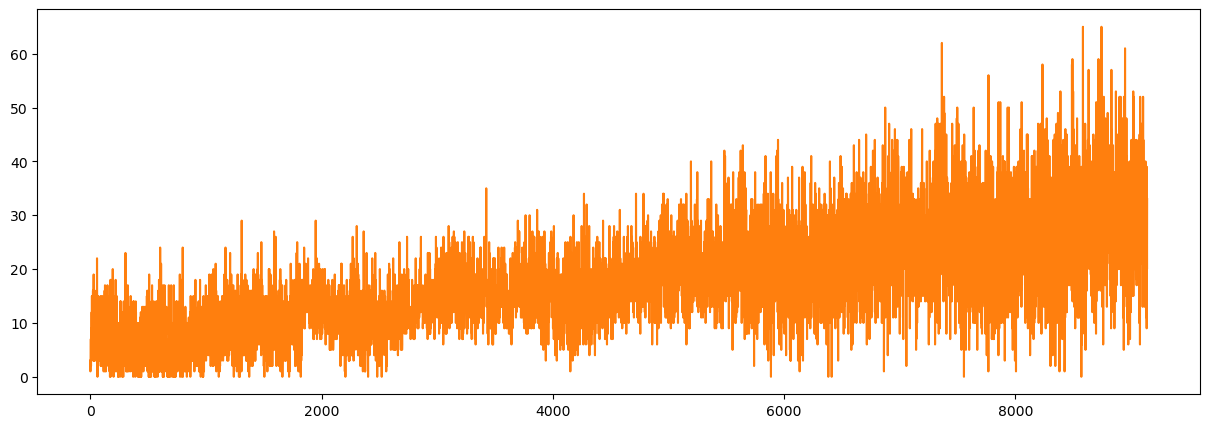

In [17]:
# Let do a genaral visualization
color_pal = sns.color_palette()
data_demand['Demand'].plot(kind = 'line', color = color_pal[1], figsize = (15,5))

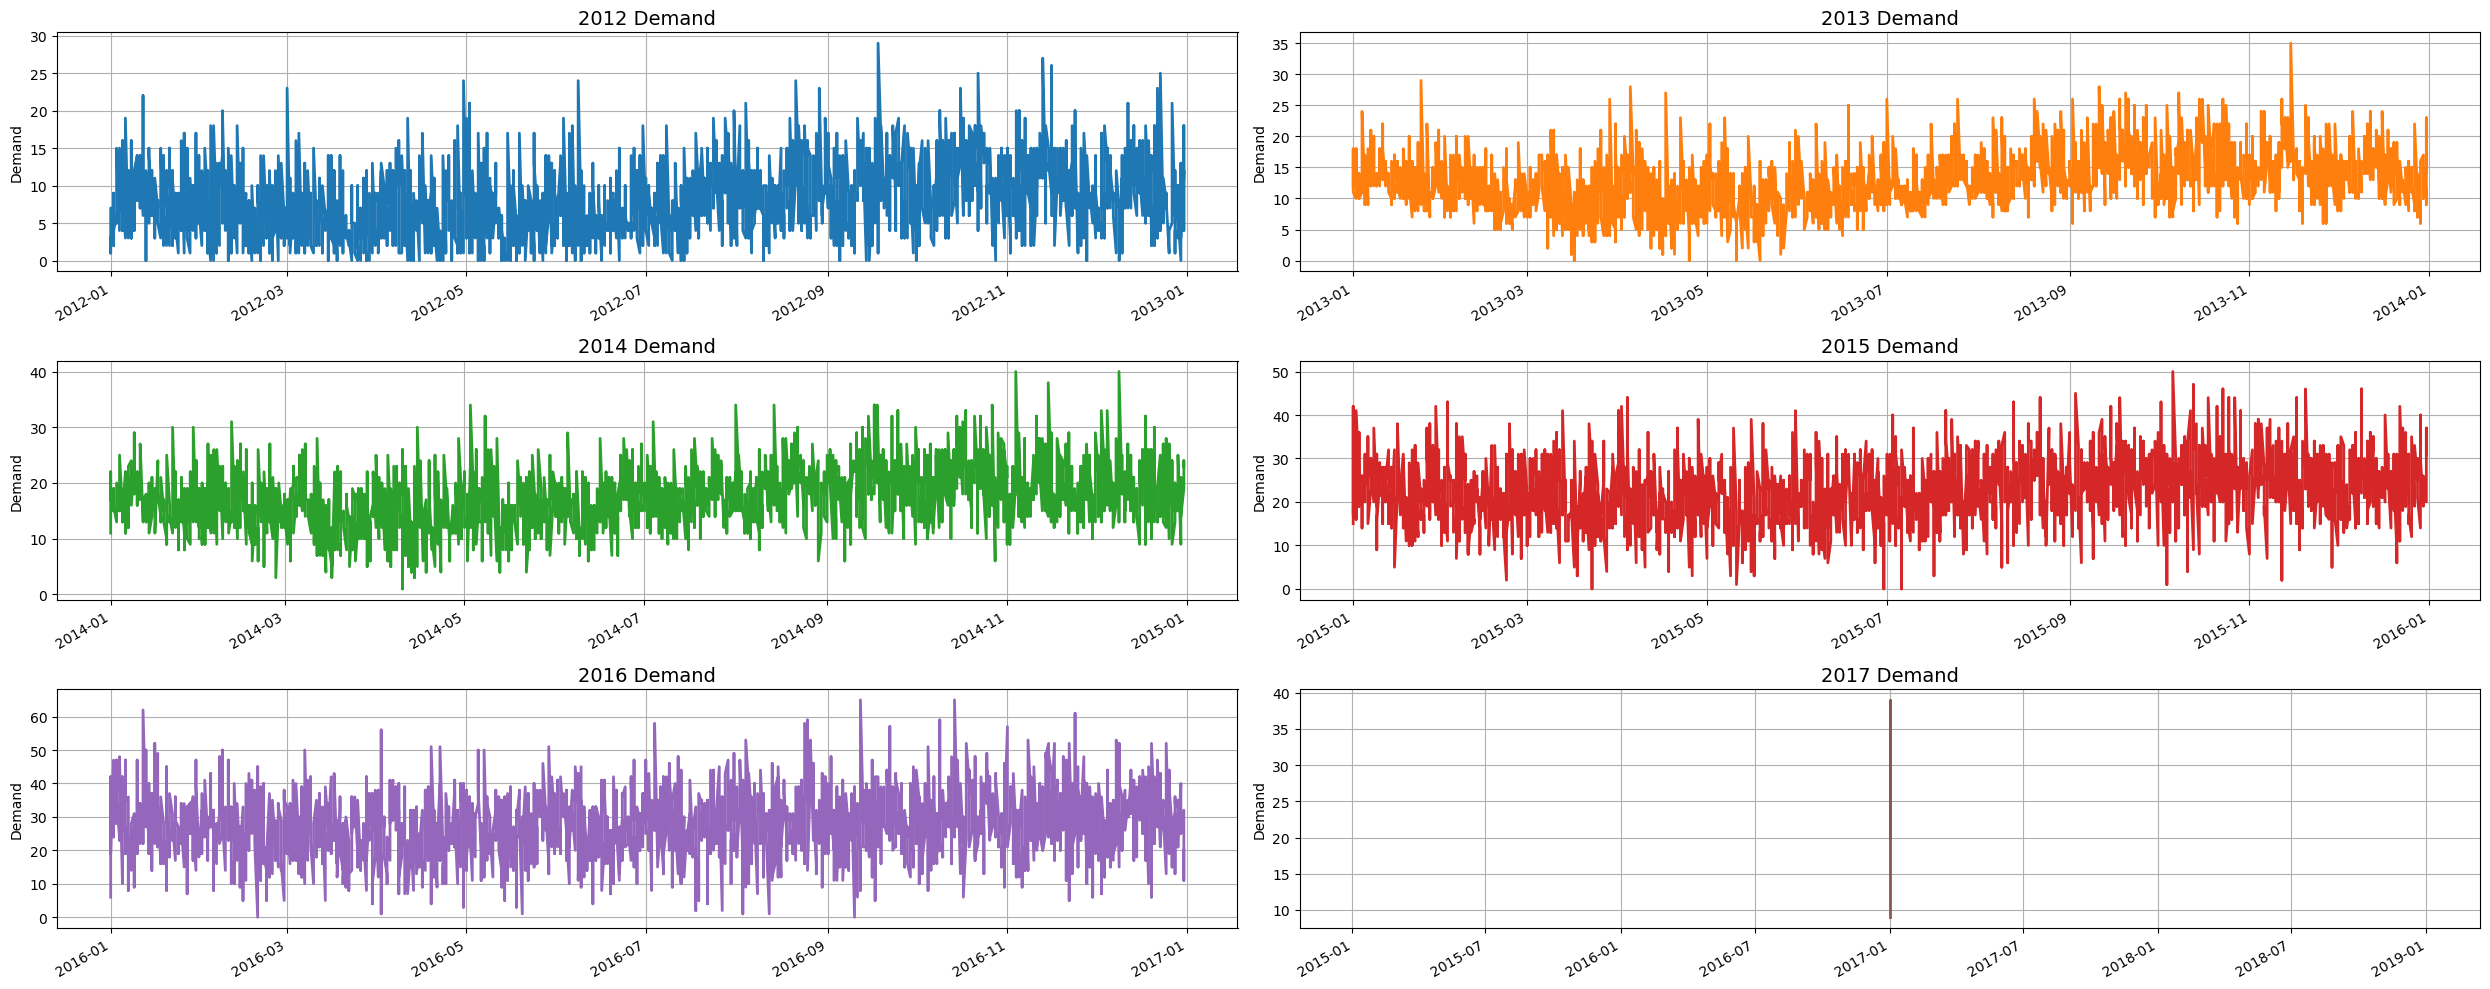

In [18]:
# For Visualization

# Let creat a plot for 5 years

# Ensure datetime index
data_demand['Date'] = pd.to_datetime(data_demand['Date'])
data_demand = data_demand.set_index('Date', drop=False)

# Color palette
color_pal = sns.color_palette()

# Create subplots
fig, axs = plt.subplots(3, 2, figsize=(25, 10))
axs = axs.flatten()

# Years to plot
years = ['2012', '2013', '2014', '2015', '2016', '2017']

for i, year in enumerate(years):
    ax = axs[i]
    
    data_demand.loc[year, 'Demand'].plot(
        ax=ax,
        color=color_pal[i],
        linewidth=2
    )
    
    ax.set_title(f'{year} Demand', fontsize=14)
    ax.set_xlabel('')
    ax.set_ylabel('Demand')
    ax.grid(True)

plt.tight_layout()
plt.show()

In [19]:
print(data_demand.columns)

Index(['Date', 'Product_id', 'Demand'], dtype='object')


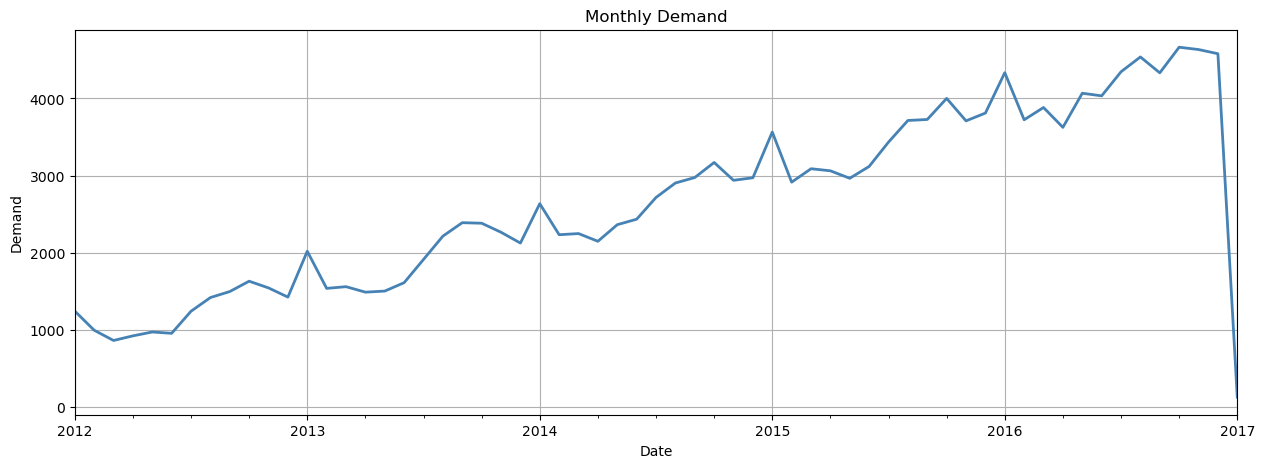

In [20]:
# Let Visualize per moth 

monthly_demand = data_demand['Demand'].resample('ME').sum()

plt.figure(figsize=(15,5))
monthly_demand.plot(color='steelblue', linewidth=2)

plt.title('Monthly Demand')
plt.xlabel('Date')
plt.ylabel('Demand')
plt.grid(True)

plt.show()

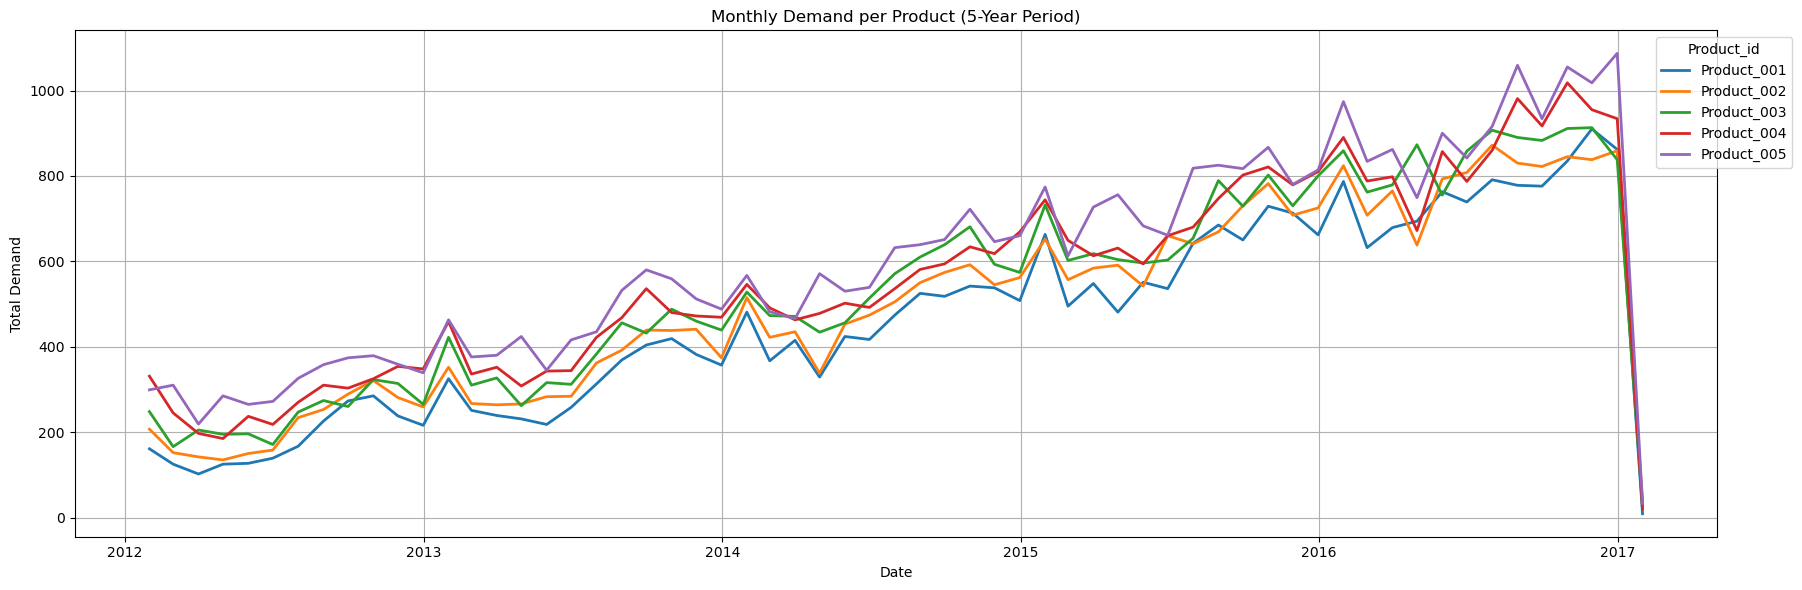

In [21]:
# Let Visualize each product total demand on monthly basis accross 5 year period

# Ensure datetime
data_demand['Date'] = pd.to_datetime(data_demand['Date'])

# Group by Product and Month
monthly_product = (
    data_demand
    .groupby(['Product_id', pd.Grouper(key='Date', freq='ME')])['Demand']
    .sum()
    .reset_index()
)

# Plot
plt.figure(figsize=(18,6))
sns.lineplot(
    data=monthly_product,
    x='Date',
    y='Demand',
    hue='Product_id',
    linewidth=2
)

plt.title('Monthly Demand per Product (5-Year Period)')
plt.xlabel('Date')
plt.ylabel('Total Demand')
plt.grid(True)

plt.legend(title='Product_id', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [22]:
### Let Check the outlier to understand the possible pike

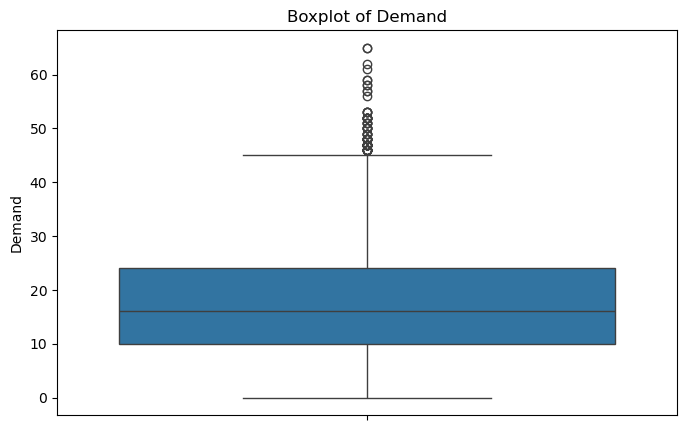

In [23]:
plt.figure(figsize=(8, 5))
sns.boxplot(y=data_demand['Demand'])

plt.title('Boxplot of Demand')
plt.ylabel('Demand')
plt.show()

## Feature Enginearing

In [24]:
# Extract day, month, and year
data_demand['Year'] = data_demand['Date'].dt.year
data_demand['Month'] = data_demand['Date'].dt.month
data_demand['Day'] = data_demand['Date'].dt.day
data_demand['DayOfWeek'] = data_demand['Date'].dt.dayofweek
data_demand['WeekOfYear'] = data_demand['Date'].dt.isocalendar().week.astype(int)

## Correlation analysis

Correlation Matrix:

              Demand      Year     Month       Day  DayOfWeek  WeekOfYear
Demand      1.000000  0.711811  0.155661 -0.010133  -0.018792    0.162207
Year        0.711811  1.000000 -0.001853 -0.001938   0.003281    0.010047
Month       0.155661 -0.001853  1.000000  0.011152  -0.004244    0.963427
Day        -0.010133 -0.001938  0.011152  1.000000  -0.000285    0.060295
DayOfWeek  -0.018792  0.003281 -0.004244 -0.000285   1.000000    0.001381
WeekOfYear  0.162207  0.010047  0.963427  0.060295   0.001381    1.000000


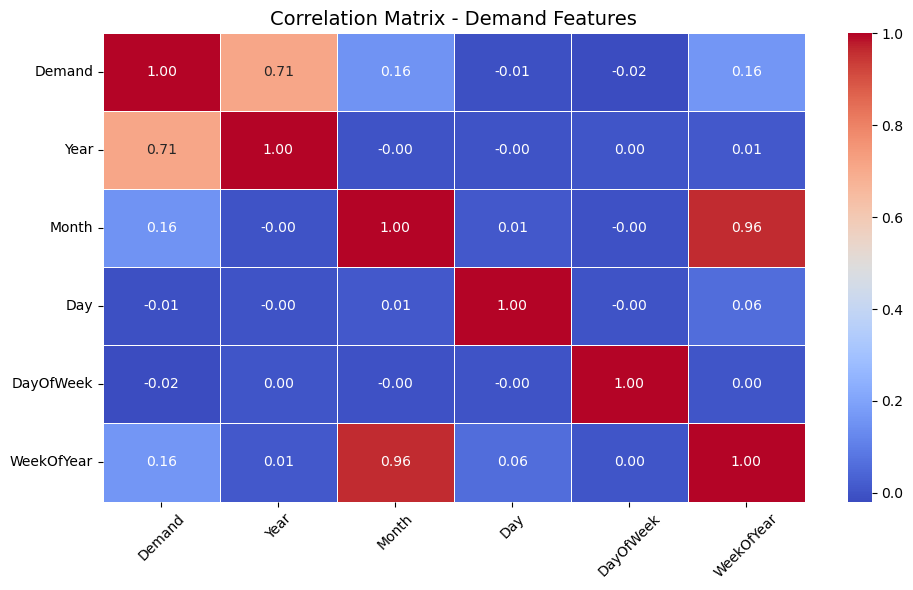

In [25]:
# ---------------------------------------------------
# 1. Select only numeric features for correlation
# ---------------------------------------------------
# Correlation only works on numerical data, so we exclude:
# - object columns (e.g., Product_id)
# - datetime columns (e.g., Date)

numeric_df = data_demand.select_dtypes(include=['int64', 'int32'])

# ---------------------------------------------------
# 2. Compute correlation matrix
# ---------------------------------------------------
# This shows linear relationships between variables
# Values range from -1 (negative) to +1 (positive)

corr_matrix = numeric_df.corr()

# Optional: display matrix in console
print("Correlation Matrix:\n")
print(corr_matrix)

# ---------------------------------------------------
# 3. Visualize correlation using heatmap
# ---------------------------------------------------
# Heatmap makes it easier to identify:
# - strong positive correlations (red)
# - strong negative correlations (blue)
# - weak/no correlations (light colors)

plt.figure(figsize=(10, 6))

sns.heatmap(
    corr_matrix,
    annot=True,          # show values inside cells
    fmt=".2f",           # format numbers to 2 decimals
    cmap='coolwarm',     # color theme
    linewidths=0.5       # spacing between cells
)

# ---------------------------------------------------
# 4. Plot styling
# ---------------------------------------------------
plt.title("Correlation Matrix - Demand Features", fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Observation

📈 1. Strong trend over time
Demand ↔ Year = 0.71 (strong positive)
👉 Demand is heavily influenced by long-term growth or decline
👉 Clear upward/downward trend across years
🌤 2. Weak seasonality effect
Month ↔ Demand = 0.16
WeekOfYear ↔ Demand = 0.16

👉 Seasonal patterns exist but are weak and not strongly linear

⚠️ 3. High redundancy (multicollinearity)
Month ↔ WeekOfYear = 0.96 (very high)

👉 Both features carry almost identical information
👉 You should keep only one or use cyclical encoding

📉 4. No daily pattern
Day ↔ Demand ≈ -0.01
DayOfWeek ↔ Demand ≈ -0.02

👉 Daily-level features have no meaningful impact

🧠 5. Key insight

👉 Demand is mainly driven by:

long-term trend (Year)
weak seasonal effects
not daily behavior

## Modeling

### Let start with basic model Linear Regression

In [26]:
# import libreries

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---------------------------------------------------
# 1. Feature Selection
# ---------------------------------------------------
# Drop non-numeric / unnecessary columns
df = data_demand.copy()

# We exclude:
# - Date (already encoded into features)
# - Product_id (categorical, not used in linear regression here)
df = df.drop(columns=['Date', 'Product_id'])

# ---------------------------------------------------
# 2. Define X (features) and y (target)
# ---------------------------------------------------
X = df.drop(columns=['Demand'])
y = df['Demand']

# ---------------------------------------------------
# 3. Time-based Train/Test Split (VERY IMPORTANT)
# ---------------------------------------------------
# We do NOT shuffle because it's time-series data
split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

# ---------------------------------------------------
# 4. Model Training
# ---------------------------------------------------
model = LinearRegression()
model.fit(X_train, y_train)

# ---------------------------------------------------
# 5. Predictions
# ---------------------------------------------------
y_pred = model.predict(X_test)

# ---------------------------------------------------
# 6. Evaluation Metrics
# ---------------------------------------------------

# MAE (Mean Absolute Error)
mae = mean_absolute_error(y_test, y_pred)

# MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

# RMSE (Root Mean Squared Error)
rmse = np.sqrt(mse)

# R-squared score
r2 = r2_score(y_test, y_pred)

# MPE (Mean Percentage Error)
mpe = np.mean((y_test - y_pred) / y_test) * 100

# ---------------------------------------------------
# 7. Print Results
# ---------------------------------------------------
print("📊 Model Evaluation Results")
print("-" * 40)
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MPE  : {mpe:.2f}%")
print(f"R²   : {r2:.4f}")

# ---------------------------------------------------
# 8. Model Interpretation
# ---------------------------------------------------
print("\n📌 Model Intercept:")
print(model.intercept_)

print("\n📌 Feature Coefficients:")
for feature, coef in zip(X.columns, model.coef_):
    print(f"{feature}: {coef:.4f}")

📊 Model Evaluation Results
----------------------------------------
MAE  : 7.80
MSE  : 97.38
RMSE : 9.87
MPE  : -inf%
R²   : 0.0248

📌 Model Intercept:
-9696.90813821582

📌 Feature Coefficients:
Year: 4.8223
Month: 0.3203
Day: -0.0117
DayOfWeek: -0.0970
WeekOfYear: 0.0279


### Observation

📊 🔍 Model Performance Observations
📉 1. Very low model accuracy
R² = 0.0248

👉 This is extremely low (almost 0)

🧠 Meaning:
This model explains only ~2.5% of demand variation
Linear regression is basically not capturing the pattern
📊 2. Error levels are high relative to signal
MAE = 7.80
RMSE = 9.87
🧠 Meaning:
On average, predictions are off by ~8 units
Large errors still exist (RMSE > MAE indicates outliers)

👉 Model is not stable

⚠️ 3. MPE = -∞ (serious issue)
🚨 This is a red flag

It happens because:

Some actual Demand values are 0
Division (y_true - y_pred) / y_true becomes invalid

👉 This metric is not reliable for your dataset


add small epsilon:
mpe = np.mean((y_test - y_pred) / (y_test + 1e-6)) * 100
📈 4. Feature importance (coefficients)
Feature	Coefficient	Interpretation
Year	+4.82	demand increases over time
Month	+0.32	weak seasonal effect
Day	-0.01	no effect
DayOfWeek	-0.09	almost no effect
WeekOfYear	+0.02	negligible effect
🧠 Key insight:
Only Year has meaningful influence
All other features are almost useless in linear form
📉 5. Intercept = -9696 (very important)
🚨 This is unusual
Meaning:
Model is trying to offset large negative baseline
Happens when:
features are weak
missing important predictors (like Product effects, lag features)
🧠 Overall Interpretation
🔴 Main conclusion:

Linear regression is NOT suitable for this dataset in its current form.

### Let apply the forcast tradicional method as the Liner Regression is not performing well

In [27]:
# Aggregate demand per day (you can also use 'ME' for monthly)
data_demand = data_demand.drop(columns=['Date'], errors='ignore')

# now i use index directly

ts = data_demand['Demand'].resample('D').sum()

In [28]:
import numpy as np
import pandas as pd

# Metrics for model evaluation
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Time series models
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet


# --------------------------------------------------
# Ensure the time series index is in datetime format
# (required for proper time-based operations)
# --------------------------------------------------
ts.index = pd.to_datetime(ts.index)


# --------------------------------------------------
# Train-test split (time-based, NOT random)
# We keep chronological order to avoid data leakage
# --------------------------------------------------
split = int(len(ts) * 0.8)
train, test = ts[:split], ts[split:]


# --------------------------------------------------
# Evaluation function (same metrics for all models)
# MAE  -> average absolute error
# RMSE -> penalizes large errors more
# R²   -> goodness of fit (can be negative in forecasting)
# --------------------------------------------------
def evaluate_model(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }


# Store results from all models
results = []


# --------------------------------------------------
# 📉 1. Moving Average (Baseline model)
# Uses the mean of last 'window' observations
# Very simple → acts as a benchmark
# --------------------------------------------------
window = 7  # e.g., weekly smoothing if data is daily

# Compute last rolling average from training set
ma_value = train.rolling(window).mean().iloc[-1]

# Predict constant value for entire test period
pred_ma = pd.Series([ma_value] * len(test), index=test.index)

# Evaluate model
results.append(evaluate_model("Moving Average", test, pred_ma))


# --------------------------------------------------
# 📉 2. ARIMA (captures trend + autocorrelation)
# order = (p,d,q)
# p = autoregression, d = differencing, q = moving average
# --------------------------------------------------
arima_model = ARIMA(train, order=(2,1,2))
arima_fit = arima_model.fit()

# Forecast future values
forecast_arima = arima_fit.forecast(steps=len(test))

# Align predictions with test index
forecast_arima = pd.Series(forecast_arima, index=test.index)

# Evaluate model
results.append(evaluate_model("ARIMA", test, forecast_arima))


# --------------------------------------------------
# 📈 3. SARIMA (ARIMA + seasonality)
# seasonal_order = (P,D,Q,s)
# s = season length (e.g., 12 for monthly, 7 for daily weekly seasonality)
# --------------------------------------------------
sarima_model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12),  # adjust depending on your data frequency
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit(disp=False)

# Forecast
forecast_sarima = sarima_fit.forecast(steps=len(test))

# Align index
forecast_sarima = pd.Series(forecast_sarima, index=test.index)

# Evaluate model
results.append(evaluate_model("SARIMA", test, forecast_sarima))


# --------------------------------------------------
# 📊 4. Prophet (handles trend + seasonality + holidays)
# Requires dataframe with:
# ds = date column
# y  = target variable
# --------------------------------------------------
df_prophet = ts.reset_index()
df_prophet.columns = ['ds', 'y']

# Same split as before
train_df = df_prophet.iloc[:split]
test_df = df_prophet.iloc[split:]

# Initialize model with multiple seasonalities
model = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=True
)

# Train model
model.fit(train_df)

# Create future dates for prediction
future = model.make_future_dataframe(periods=len(test_df), freq='D')

# Generate forecast
forecast = model.predict(future)

# Extract predicted values
forecast_values = forecast[['ds', 'yhat']].set_index('ds')

# Keep only test period predictions
pred_prophet = forecast_values.loc[test_df['ds']]['yhat'].values

# Evaluate model
results.append(
    evaluate_model(
        "Prophet",
        test_df['y'].values,
        pred_prophet
    )
)


# --------------------------------------------------
# 📊 Final comparison of all models
# Sorted by RMSE (lower is better)
# --------------------------------------------------
results_df = pd.DataFrame(results)

print("\n📊 Model Comparison")
print(results_df.sort_values(by="RMSE"))

13:26:32 - cmdstanpy - INFO - Chain [1] start processing
13:26:32 - cmdstanpy - INFO - Chain [1] done processing



📊 Model Comparison
            Model        MAE       RMSE        R2
3         Prophet  18.517494  22.979840  0.153354
2          SARIMA  19.436958  24.017200  0.075190
0  Moving Average  22.918033  28.554044 -0.307203
1           ARIMA  23.218446  28.923587 -0.341257


### Observation

Prophet, is the tradictional model that give us the best result, MAE 18 and the model explain 15% of variance, way better than other model.
But, we need a better result.

we will apply the advance model to see if we can have a best result.

### Let Visualize the Prophet preformance

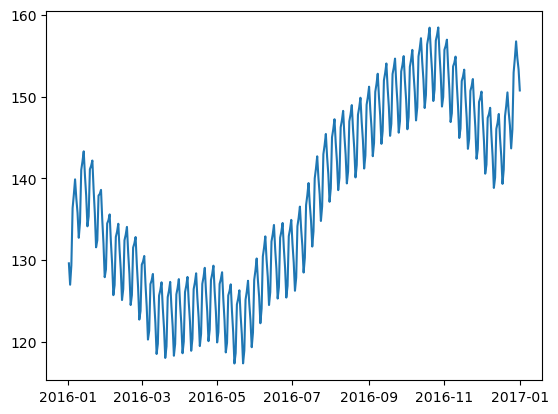

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


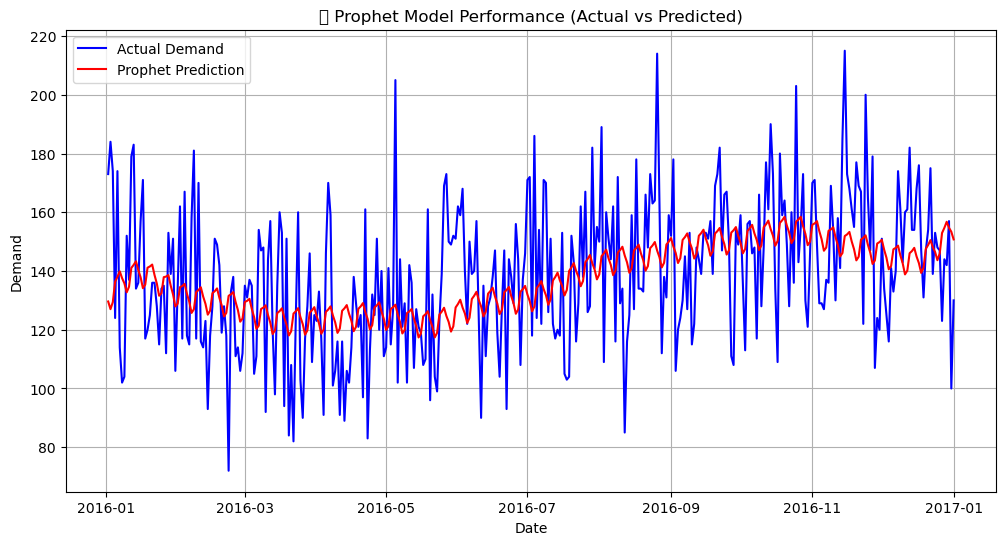

In [29]:
# Plot results of prophet, to analyse the actua vs prediction

# --------------------------------------------------
# Plot Prophet predictions vs actual demand
# --------------------------------------------------


plt.plot(test_df['ds'], pred_prophet),



# --------------------------------------------------
# Create figure with defined size for better readability
# --------------------------------------------------
plt.figure(figsize=(12, 6))


# --------------------------------------------------
# Plot ACTUAL demand values (ground truth)
# test_df['y'] contains real observed demand values
# --------------------------------------------------
plt.plot(
    test_df['ds'],              # time axis (dates)
    test_df['y'].values,        # actual demand values
    label="Actual Demand",      # legend label
    color="blue"                # line color for clarity
)


# --------------------------------------------------
# Plot PROPHET predictions
# pred_prophet contains model forecasts (yhat values)
# --------------------------------------------------
plt.plot(
    test_df['ds'],              # same time axis
    pred_prophet,               # predicted demand from Prophet
    label="Prophet Prediction", # legend label
    color="red"                 # prediction line color
)


# --------------------------------------------------
# Add chart title and axis labels
# --------------------------------------------------
plt.title("📊 Prophet Model Performance (Actual vs Predicted)")
plt.xlabel("Date")
plt.ylabel("Demand")


# --------------------------------------------------
# Add legend to distinguish lines
# --------------------------------------------------
plt.legend()


# --------------------------------------------------
# Add grid for better visual interpretation
# --------------------------------------------------
plt.grid(True)


# --------------------------------------------------
# Display the plot
# --------------------------------------------------
plt.show()

In [30]:
data_demand.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 9140 entries, 2012-01-01 to 2017-01-01
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Product_id  9140 non-null   object
 1   Demand      9140 non-null   int64 
 2   Year        9140 non-null   int32 
 3   Month       9140 non-null   int32 
 4   Day         9140 non-null   int32 
 5   DayOfWeek   9140 non-null   int32 
 6   WeekOfYear  9140 non-null   int64 
dtypes: int32(4), int64(2), object(1)
memory usage: 428.4+ KB


## Advanced Model

In [31]:
# Libreries


## Let apply Hyperparametre tuning to improve the model performance

### Common Setup hyperparametre

In [32]:
# Librerie

import numpy as np
import pandas as pd
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --------------------------------------------------
# 1. PREPARE DATA
# --------------------------------------------------
df_a = data_demand.copy()
df_a.index = pd.to_datetime(df_a.index)

# Sort by product & date
df_a = df_a.sort_values(['Product_id', df_a.index.name])

# Encode product_id
df_a['Product_id'] = df_a['Product_id'].astype('category').cat.codes

# --------------------------------------------------
# 2. CREATE LAG FEATURES
# --------------------------------------------------
for lag in [1, 2, 3, 7, 14]:
    df_a[f'lag_{lag}'] = df_a.groupby('Product_id')['Demand'].shift(lag)

# Rolling features
df_a['rolling_mean_7'] = df_a.groupby('Product_id')['Demand'].shift(1).rolling(7).mean()
df_a['rolling_std_7'] = df_a.groupby('Product_id')['Demand'].shift(1).rolling(7).std()
df_a['rolling_mean_14'] = df_a.groupby('Product_id')['Demand'].shift(1).rolling(14).mean()
df_a['rolling_std_14'] = df_a.groupby('Product_id')['Demand'].shift(1).rolling(14).std()

# Drop rows with NaN
df_a = df_a.dropna()

# --------------------------------------------------
# 3. CYCLICAL ENCODING
# --------------------------------------------------
df_a['month_sin'] = np.sin(2 * np.pi * df_a['Month']/12)
df_a['month_cos'] = np.cos(2 * np.pi * df_a['Month']/12)
df_a['week_sin'] = np.sin(2 * np.pi * df_a['WeekOfYear']/52)
df_a['week_cos'] = np.cos(2 * np.pi * df_a['WeekOfYear']/52)

# --------------------------------------------------
# 4. DEFINE FEATURES AND TARGET
# --------------------------------------------------
features = [
    'Product_id', 'Year', 'Day', 'DayOfWeek', 'WeekOfYear',
    'lag_1', 'lag_2', 'lag_3', 'lag_7', 'lag_14',
    'rolling_mean_7', 'rolling_std_7', 'rolling_mean_14', 'rolling_std_14',
    'month_sin', 'month_cos', 'week_sin', 'week_cos'
]
target = 'Demand'

X = df_a[features]
y = df_a[target]

# --------------------------------------------------
# 5. TIME-BASED TRAIN / TEST SPLIT
# --------------------------------------------------
split = int(len(df_a) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# Apply log1p transform to training target
y_train_log = np.log1p(y_train)

# --------------------------------------------------
# 6. EVALUATION FUNCTION
# --------------------------------------------------
def evaluate(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    mpe = np.mean((y_true - y_pred) / np.maximum(y_true, 1)) * 100
    return mae, mse, rmse, mpe, r2

# --------------------------------------------------
# 7. DEFINE MODELS
# --------------------------------------------------
models = {
    "XGBoost": XGBRegressor(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42),
    "LightGBM": LGBMRegressor(n_estimators=300, num_leaves=31, learning_rate=0.05, random_state=42),
    "CatBoost": CatBoostRegressor(iterations=300, learning_rate=0.05, depth=6, verbose=0, random_state=42),
    "RandomForest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=42)
}

# --------------------------------------------------
# 8. TRAIN AND EVALUATE MODELS WITH LOG TRANSFORM
# --------------------------------------------------
results = []

for name, model in models.items():
    # Train on log-transformed target
    model.fit(X_train, y_train_log)
    
    # Predict and back-transform
    preds_log = model.predict(X_test)
    preds = np.expm1(preds_log)
    
    # Evaluate
    mae, mse, rmse, mpe, r2 = evaluate(y_test, preds)
    
    results.append({
        "Model": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MPE (%)": mpe,
        "R2": r2
    })

# --------------------------------------------------
# 9. DISPLAY RESULTS
# --------------------------------------------------
results_df = pd.DataFrame(results)
print("\n📊 Advanced ML Forecasting Results (Log-Transformed Target)")
print(results_df.sort_values(by="RMSE"))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000427 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 7256, number of used features: 18
[LightGBM] [Info] Start training from score 2.725774

📊 Advanced ML Forecasting Results (Log-Transformed Target)
          Model       MAE        MSE      RMSE   MPE (%)        R2
2      CatBoost  5.604552  56.448423  7.513217 -8.969897  0.464470
1      LightGBM  5.693566  57.455919  7.579968 -8.876021  0.454912
0       XGBoost  5.793745  58.953781  7.678137 -7.021736  0.440702
3  RandomForest  5.847259  60.801471  7.797530 -6.717462  0.423173


In [33]:
# Time series CV
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_squared_error
tscv = TimeSeriesSplit(n_splits=3)

scorer = make_scorer(mean_squared_error, greater_is_better=False)

In [34]:
# XGBoost Tuning

from sklearn.model_selection import RandomizedSearchCV

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)

xgb_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0]
}

xgb_search = RandomizedSearchCV(
    xgb,
    xgb_params,
    n_iter=10,
    scoring=scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X_train, y_train)

print("Best XGB Params:", xgb_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best XGB Params: {'subsample': 0.6, 'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.01, 'colsample_bytree': 1.0}


In [35]:
# LightGBN Tuning

lgbm = LGBMRegressor(random_state=42)

lgbm_params = {
    "n_estimators": [100, 300, 500],
    "num_leaves": [20, 31, 50, 100],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [-1, 5, 10],
    "subsample": [0.6, 0.8, 1.0]
}

lgbm_search = RandomizedSearchCV(
    lgbm,
    lgbm_params,
    n_iter=10,
    scoring=scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

lgbm_search.fit(X_train, y_train)

print("Best LGBM Params:", lgbm_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001099 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 7256, number of used features: 18
[LightGBM] [Info] Start training from score 17.128997
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGB

In [36]:
# CatBoost Tuning

cat = CatBoostRegressor(verbose=0, random_state=42)

cat_params = {
    "iterations": [200, 500],
    "depth": [4, 6, 8, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "l2_leaf_reg": [1, 3, 5, 7, 9]
}

cat_search = RandomizedSearchCV(
    cat,
    cat_params,
    n_iter=10,
    scoring=scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

cat_search.fit(X_train, y_train)

print("Best CatBoost Params:", cat_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best CatBoost Params: {'learning_rate': 0.01, 'l2_leaf_reg': 3, 'iterations': 500, 'depth': 8}


In [37]:
# Random Forest Tuning

rf = RandomForestRegressor(random_state=42)

rf_params = {
    "n_estimators": [100, 300, 500],
    "max_depth": [5, 10, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_search = RandomizedSearchCV(
    rf,
    rf_params,
    n_iter=10,
    scoring=scorer,
    cv=tscv,
    verbose=1,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)

print("Best RF Params:", rf_search.best_params_)

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best RF Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 5}


In [38]:
# Final Best Model Evaluation

best_models = {
    "XGBoost": xgb_search.best_estimator_,
    "LightGBM": lgbm_search.best_estimator_,
    "CatBoost": cat_search.best_estimator_,
    "RandomForest": rf_search.best_estimator_
}

results = []

for name, model in best_models.items():
    preds = model.predict(X_test)

    mae = np.mean(np.abs(y_test - preds))
    mse = np.mean((y_test - preds)**2)
    rmse = np.sqrt(mse)
    mpe = np.mean((y_test - preds) / np.maximum(y_test, 1)) * 100
    r2 = model.score(X_test, y_test)

    results.append([name, mae, mse, rmse, mpe, r2])

results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "MSE", "RMSE", "MPE", "R2"
])

print(results_df.sort_values("RMSE"))

          Model       MAE        MSE      RMSE        MPE        R2
2      CatBoost  5.472991  52.259508  7.229074 -18.915391  0.504211
0       XGBoost  5.495597  52.462777  7.243119 -18.644744  0.502282
1      LightGBM  5.514652  53.216936  7.294994 -17.280587  0.495128
3  RandomForest  5.578598  53.663634  7.325547 -20.154603  0.490890


In [39]:
data_demand.describe()

,Demand,Year,Month,Day,DayOfWeek,WeekOfYear
count,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000,9140.000000
mean,17.673961,2014.001641,6.518053,15.727024,3.001641,26.615427
std,9.796141,1.416416,3.450873,8.807207,2.000792,15.077156
min,0.000000,2012.000000,1.000000,1.000000,0.000000,1.000000
25%,10.000000,2013.000000,4.000000,8.000000,1.000000,14.000000
50%,16.000000,2014.000000,7.000000,16.000000,3.000000,27.000000
75%,24.000000,2015.000000,10.000000,23.000000,5.000000,40.000000
max,65.000000,2017.000000,12.000000,31.000000,6.000000,53.000000


### Feature Importance

🏆 Best Model: CatBoost


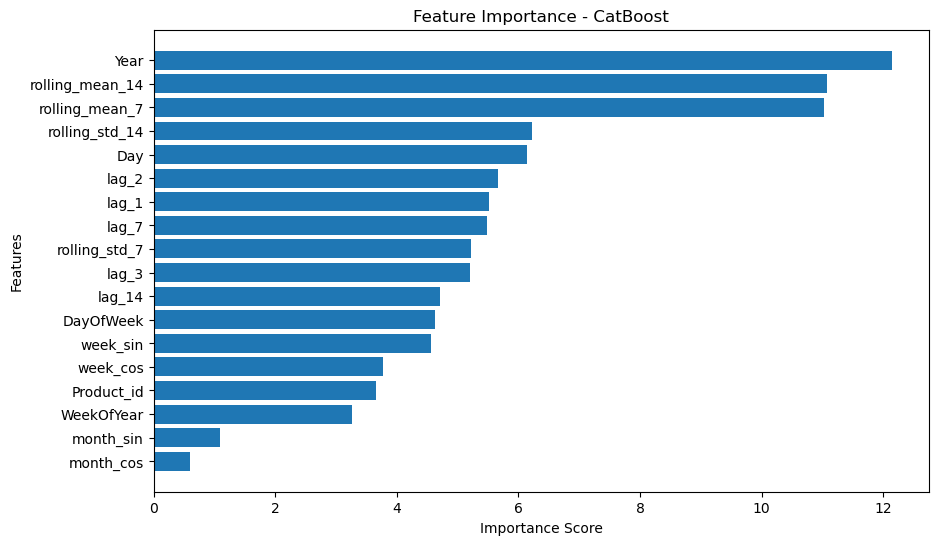

In [40]:
import matplotlib.pyplot as plt
import pandas as pd

# --------------------------------------------------
# 1. Identify best model from results table
# --------------------------------------------------
best_model_name = results_df.sort_values(by="RMSE").iloc[0]["Model"]

print(f"🏆 Best Model: {best_model_name}")


# --------------------------------------------------
# 2. Re-train best model (needed for feature importance)
# --------------------------------------------------

if best_model_name == "XGBoost":
    best_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.1)
    
elif best_model_name == "LightGBM":
    best_model = LGBMRegressor(n_estimators=200)

elif best_model_name == "CatBoost":
    best_model = CatBoostRegressor(verbose=0)

elif best_model_name == "RandomForest":
    best_model = RandomForestRegressor(n_estimators=200)

# Fit on full training data
best_model.fit(X_train, y_train)


# --------------------------------------------------
# 3. Extract feature importance
# --------------------------------------------------

# Tree-based models (all your models support this)
importances = best_model.feature_importances_

feature_names = X_train.columns

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

# Sort by importance
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)


# --------------------------------------------------
# 4. Plot feature importance
# --------------------------------------------------

plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df["Feature"], feature_importance_df["Importance"])
plt.gca().invert_yaxis()  # most important on top

plt.title(f"Feature Importance - {best_model_name}")
plt.xlabel("Importance Score")
plt.ylabel("Features")

plt.show()

### Performance metric Visualization

### 📊 VISUALIZATION

C:\Users\HP\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


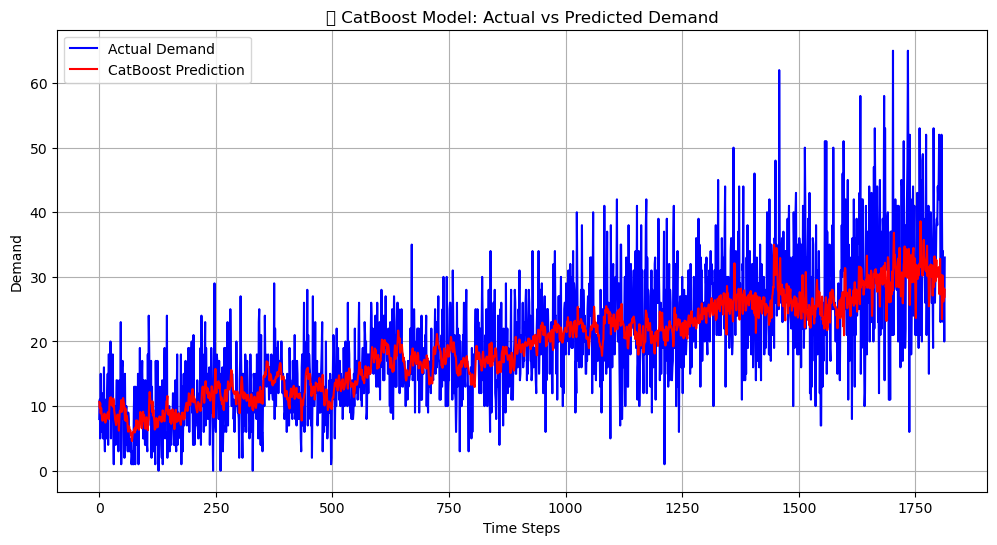

In [41]:
# --------------------------------------------------
# 1. Re-train CatBoost on the full training data
# --------------------------------------------------
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=0,
    random_state=42
)

cat_model.fit(X_train, y_train)

# --------------------------------------------------
# 2. Predict on test set
# --------------------------------------------------
preds_cat = cat_model.predict(X_test)

# --------------------------------------------------
# 3. Plot Actual vs Predicted
# --------------------------------------------------
plt.figure(figsize=(12, 6))

# Actual demand
plt.plot(y_test.values, label='Actual Demand', color='blue')

# Predicted demand
plt.plot(preds_cat, label='CatBoost Prediction', color='red')

plt.title("📊 CatBoost Model: Actual vs Predicted Demand")
plt.xlabel("Time Steps")
plt.ylabel("Demand")
plt.legend()
plt.grid(True)
plt.show()

## Enventory Optimazation

In [42]:
df_a.head()

,Product_id,Demand,Year,Month,Day,DayOfWeek,WeekOfYear,lag_1,lag_2,lag_3,lag_7,lag_14,rolling_mean_7,rolling_std_7,rolling_mean_14,rolling_std_14,month_sin,month_cos,week_sin,week_cos
Date,,,,,,,,,,,,,,,,,,,,
2012-01-15,0,8,2012,1,15,6,2,7.0,6.0,6.0,5.0,3.0,8.142857,3.132016,6.357143,3.053551,0.5,0.866025,0.239316,0.970942
2012-01-16,0,10,2012,1,16,0,3,8.0,7.0,6.0,9.0,7.0,8.571429,2.819997,6.714286,2.920184,0.5,0.866025,0.354605,0.935016
2012-01-17,0,7,2012,1,17,1,3,10.0,8.0,7.0,14.0,6.0,8.714286,2.870208,6.928571,3.049950,0.5,0.866025,0.354605,0.935016
2012-01-18,0,3,2012,1,18,2,3,7.0,10.0,8.0,10.0,4.0,7.714286,1.704336,7.000000,3.038218,0.5,0.866025,0.354605,0.935016
2012-01-19,0,2,2012,1,19,3,3,3.0,7.0,10.0,6.0,6.0,6.714286,2.138090,6.928571,3.124698,0.5,0.866025,0.354605,0.935016


In [43]:
print(df_a.index.name)

Date


In [44]:
print('Date' in df_a.columns)

False


In [45]:
# Option 1: Reset index (recommended)
df_a = df_a.reset_index()

# Option 2: If you want to keep the index as well
df_a = df_a.reset_index(drop=False)

In [46]:
print(df_a.head())
print(df_a.columns)

   index       Date  Product_id  Demand  Year  Month  Day  DayOfWeek  \
0      0 2012-01-15           0       8  2012      1   15          6   
1      1 2012-01-16           0      10  2012      1   16          0   
2      2 2012-01-17           0       7  2012      1   17          1   
3      3 2012-01-18           0       3  2012      1   18          2   
4      4 2012-01-19           0       2  2012      1   19          3   

   WeekOfYear  lag_1  ...  lag_7  lag_14  rolling_mean_7  rolling_std_7  \
0           2    7.0  ...    5.0     3.0        8.142857       3.132016   
1           3    8.0  ...    9.0     7.0        8.571429       2.819997   
2           3   10.0  ...   14.0     6.0        8.714286       2.870208   
3           3    7.0  ...   10.0     4.0        7.714286       1.704336   
4           3    3.0  ...    6.0     6.0        6.714286       2.138090   

   rolling_mean_14  rolling_std_14  month_sin  month_cos  week_sin  week_cos  
0         6.357143        3.053551   

In [47]:
# Let Copy the dataset for optimization model
data_demand_a = df_a.copy()
data_product_a = data_Product.copy()
data_inventory_a = data_inventory.copy()

In [48]:
# Let Joint the 3 tables in one dataset

# Check the structure of the demand dataset
print("📌 Demand Dataset Info")
data_demand_a.info()
print("\n" + "-"*50 + "\n")

# Check the structure of the product dataset
print("📌 Product Dataset Info")
data_product_a.info()
print("\n" + "-"*50 + "\n")

# Check the structure of the inventory dataset
print("📌 Inventory Dataset Info")
data_inventory_a.info()
print("\n" + "-"*50 + "\n")


📌 Demand Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9070 entries, 0 to 9069
Data columns (total 22 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   index            9070 non-null   int64         
 1   Date             9070 non-null   datetime64[ns]
 2   Product_id       9070 non-null   int8          
 3   Demand           9070 non-null   int64         
 4   Year             9070 non-null   int32         
 5   Month            9070 non-null   int32         
 6   Day              9070 non-null   int32         
 7   DayOfWeek        9070 non-null   int32         
 8   WeekOfYear       9070 non-null   int64         
 9   lag_1            9070 non-null   float64       
 10  lag_2            9070 non-null   float64       
 11  lag_3            9070 non-null   float64       
 12  lag_7            9070 non-null   float64       
 13  lag_14           9070 non-null   float64       
 14  rolling_mean_7   9

In [49]:
print("Inventory columns:", data_inventory_a.columns.tolist())

Inventory columns: ['Date', 'Product_ID', 'Demand', 'Seasonality', 'Lead_Time_Days']


### Let Joint all the table

In [50]:
# --------------------------------------------------
# 1. CLEAN COLUMN NAMES
# --------------------------------------------------
for df in [data_demand_a, data_product_a, data_inventory_a]:
    df.columns = df.columns.str.strip()
    df.columns = df.columns.str.replace(" ", "_")

# --------------------------------------------------
# 2. DATETIME CONVERSION
# --------------------------------------------------
data_demand_a['Date'] = pd.to_datetime(data_demand_a['Date'], errors='coerce')
data_inventory_a['Date'] = pd.to_datetime(data_inventory_a['Date'], errors='coerce')

# --------------------------------------------------
# 3. STANDARDIZE PRODUCT IDs
# --------------------------------------------------
data_demand_a['Product_id'] = data_demand_a['Product_id'].astype(str).str.strip()
data_product_a['Product_Code'] = data_product_a['Product_Code'].astype(str).str.strip()
data_inventory_a['Product_ID'] = data_inventory_a['Product_ID'].astype(str).str.strip()

data_inventory_a = data_inventory_a.rename(columns={'Product_ID': 'Product_id'})
data_product_a = data_product_a.rename(columns={'Product_Code': 'Product_id'})

# Reset index if Date is index
if 'Date' not in data_demand_a.columns and data_demand_a.index.name is not None:
    data_demand_a = data_demand_a.reset_index()

data_demand_a = data_demand_a.loc[:, ~data_demand_a.columns.duplicated()]

# --------------------------------------------------
# 4. MERGE WITH FULL OUTER JOIN
# --------------------------------------------------
# Merge Demand + Inventory (Full Outer)
df = pd.merge(
    data_demand_a,
    data_inventory_a[['Product_id', 'Date', 'Seasonality', 'Lead_Time_Days']],
    how='outer',          # ← Changed to outer
    on=['Product_id', 'Date']
)

# Merge with Product dataset
df = pd.merge(
    df,
    data_product_a[['Product_id', 'Warehouse', 'Product_Category']],
    how='outer',           # Keep as left here (or change to 'outer' if needed)
    on='Product_id'
)

# --------------------------------------------------
# 5. FINAL CHECKS
# --------------------------------------------------
print("✅ Merged Dataset Shape:", df.shape)
print("\n✅ Merged Dataset Info")
df.info()

print("\nNull counts for key columns:")
print(df[['Seasonality', 'Lead_Time_Days', 'Warehouse', 'Product_Category']].isnull().sum())

print("\nSample data:")
print(df[['Date', 'Product_id', 'Seasonality', 'Lead_Time_Days', 
           'Warehouse', 'Product_Category']].head(10))

✅ Merged Dataset Shape: (1067645, 26)

✅ Merged Dataset Info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067645 entries, 0 to 1067644
Data columns (total 26 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   index             9070 non-null     float64       
 1   Date              19070 non-null    datetime64[ns]
 2   Product_id        1067645 non-null  object        
 3   Demand            9070 non-null     float64       
 4   Year              9070 non-null     float64       
 5   Month             9070 non-null     float64       
 6   Day               9070 non-null     float64       
 7   DayOfWeek         9070 non-null     float64       
 8   WeekOfYear        9070 non-null     float64       
 9   lag_1             9070 non-null     float64       
 10  lag_2             9070 non-null     float64       
 11  lag_3             9070 non-null     float64       
 12  lag_7             9070 non-null     f

In [51]:
# Let check Missing Values
df.isnull().sum()

index               1058575
Date                1048575
Product_id                0
Demand              1058575
Year                1058575
Month               1058575
Day                 1058575
DayOfWeek           1058575
WeekOfYear          1058575
lag_1               1058575
lag_2               1058575
lag_3               1058575
lag_7               1058575
lag_14              1058575
rolling_mean_7      1058575
rolling_std_7       1058575
rolling_mean_14     1058575
rolling_std_14      1058575
month_sin           1058575
month_cos           1058575
week_sin            1058575
week_cos            1058575
Seasonality         1057645
Lead_Time_Days      1057645
Warehouse             19070
Product_Category      19070
dtype: int64

### Let append the Catboost Prediction on joined dataset.

In [52]:
# --------------------------------------------------
# 1. Use your already trained model
# --------------------------------------------------
preds_cat = cat_model.predict(X_test)

# --------------------------------------------------
# 2. Append Predictions Safely
# --------------------------------------------------
df_with_pred = df.copy()

# Reset index to make sure we have clean integer index
df_with_pred = df_with_pred.reset_index(drop=True)

# Add predictions using position (safest way)
df_with_pred.loc[df_with_pred.index[-len(preds_cat):], 'CatBoost_Prediction'] = preds_cat

# Optional: Add actual values
df_with_pred.loc[df_with_pred.index[-len(y_test):], 'Actual_Demand'] = y_test.values

# --------------------------------------------------
# 3. Verification
# --------------------------------------------------
print("✅ Predictions appended successfully!")
print(f"Total rows: {len(df_with_pred)}")
print(f"Predictions added: {df_with_pred['CatBoost_Prediction'].notna().sum()}")

print("\nLast 10 rows with predictions:")
print(df_with_pred[['Date', 'Product_id', 'Demand', 
                    'CatBoost_Prediction', 'Actual_Demand']].tail(10))

✅ Predictions appended successfully!
Total rows: 1067645
Predictions added: 1814

Last 10 rows with predictions:
        Date    Product_id  Demand  CatBoost_Prediction  Actual_Demand
1067635  NaT  Product_2172     NaN            27.319089           23.0
1067636  NaT  Product_2172     NaN            30.307263           30.0
1067637  NaT  Product_2172     NaN            28.008059           52.0
1067638  NaT  Product_2172     NaN            23.460371           39.0
1067639  NaT  Product_2172     NaN            30.244525           28.0
1067640  NaT  Product_2172     NaN            28.429183           34.0
1067641  NaT  Product_2172     NaN            26.186827           23.0
1067642  NaT  Product_2172     NaN            28.257844           28.0
1067643  NaT  Product_2172     NaN            26.786399           20.0
1067644  NaT  Product_2172     NaN            27.995051           33.0


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067645 entries, 0 to 1067644
Data columns (total 26 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   index             9070 non-null     float64       
 1   Date              19070 non-null    datetime64[ns]
 2   Product_id        1067645 non-null  object        
 3   Demand            9070 non-null     float64       
 4   Year              9070 non-null     float64       
 5   Month             9070 non-null     float64       
 6   Day               9070 non-null     float64       
 7   DayOfWeek         9070 non-null     float64       
 8   WeekOfYear        9070 non-null     float64       
 9   lag_1             9070 non-null     float64       
 10  lag_2             9070 non-null     float64       
 11  lag_3             9070 non-null     float64       
 12  lag_7             9070 non-null     float64       
 13  lag_14            9070 non-null     float6

In [54]:
# 📦 Average demand
avg_demand = preds_cat.mean()

In [55]:
# Demand stand diviation
demand_std = df["Demand"].std()

In [56]:
#  SAFETY STOCK
service_level_z = 1.65  # 95% service level
lead_time = df.loc[0, 'Lead_Time_Days']
safety_stock = service_level_z * demand_std * np.sqrt(lead_time)

In [57]:
# 🔁 REORDER POINT (ROP)
reorder_point = avg_demand * lead_time + safety_stock

In [58]:
# 🔟 FINAL INVENTORY POLICY OUTPUT

policy = pd.DataFrame({
    'avg_daily_demand': [avg_demand],
    'safety_stock': [safety_stock],
    'reorder_point': [reorder_point]
})

print(policy)


   avg_daily_demand  safety_stock  reorder_point
0         19.227906           NaN            NaN


In [59]:
# Let safe the datset
df_with_pred.to_csv('final_dataset_with_catboost_predictions.csv', index=False)

print("🎉 Final dataset saved as 'final_dataset_with_catboost_predictions.csv'")

🎉 Final dataset saved as 'final_dataset_with_catboost_predictions.csv'


### Final deployment code

In [60]:
from catboost import Pool

# =============================================
# CORRECT RETRAINING CODE
# =============================================

from catboost import CatBoostRegressor

# Only use categorical features that actually exist in X_train
possible_cat = ['Product_id', 'Warehouse', 'Product_Category', 'Seasonality', 'DayOfWeek']
cat_features = [col for col in possible_cat if col in X_train.columns]

print("Categorical features used for training:", cat_features)

# Retrain the model
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=6,
    verbose=100,
    random_state=42
)

print("Training new model...")
cat_model.fit(X_train, y_train, cat_features=cat_features)

print("✅ Model retrained successfully with correct categorical features!")

# =============================================
# NOW MAKE PREDICTIONS
# =============================================

features = list(X_train.columns)

df_pred = df[features].copy()

# Fix data types
for col in cat_features:
    if col in df_pred.columns:
        df_pred[col] = df_pred[col].astype(str).fillna('Missing')

for col in df_pred.columns:
    if col not in cat_features and df_pred[col].isnull().any():
        df_pred[col] = df_pred[col].fillna(0)

predictions = cat_model.predict(df_pred)

df['CatBoost_Prediction'] = predictions

print("✅ Predictions appended!")
print(df[['Date', 'Product_id', 'CatBoost_Prediction']].tail(10))

Categorical features used for training: ['Product_id', 'DayOfWeek']
Training new model...
0:	learn: 9.3298165	total: 37.2ms	remaining: 11.1s
100:	learn: 6.0383319	total: 3.61s	remaining: 7.11s
200:	learn: 5.7734329	total: 7.24s	remaining: 3.56s
299:	learn: 5.5247657	total: 10.8s	remaining: 0us
✅ Model retrained successfully with correct categorical features!
✅ Predictions appended!
        Date    Product_id  CatBoost_Prediction
1067635  NaT  Product_2172             5.649643
1067636  NaT  Product_2172             5.649643
1067637  NaT  Product_2172             5.649643
1067638  NaT  Product_2172             5.649643
1067639  NaT  Product_2172             5.649643
1067640  NaT  Product_2172             5.649643
1067641  NaT  Product_2172             5.649643
1067642  NaT  Product_2172             5.649643
1067643  NaT  Product_2172             5.649643
1067644  NaT  Product_2172             5.649643


### Save final

In [61]:
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M")
filename = f'final_dataset_with_catboost_predictions_{timestamp}.csv'

df.to_csv(filename, index=False)

print(f"✅ File saved as: {filename}")

✅ File saved as: final_dataset_with_catboost_predictions_20260503_1334.csv


## Deployment

In [62]:
import streamlit as st
import pandas as pd
from catboost import CatBoostRegressor
import datetime

# Save your trained model
cat_model.save_model('catboost_model.cbm')

print("✅ Model saved successfully as 'catboost_model.cbm'")

✅ Model saved successfully as 'catboost_model.cbm'


In [63]:
# Updated Streamlit App (app.py)

import streamlit as st
import pandas as pd
from catboost import CatBoostRegressor
from datetime import datetime

st.set_page_config(page_title="Demand Forecast", layout="wide")
st.title("📊 Demand Forecasting App - CatBoost")

# -------------------------- Load Model --------------------------
@st.cache_resource
def load_model():
    model = CatBoostRegressor()
    model.load_model('catboost_model.cbm')
    return model

# -------------------------- Load and Fix Data --------------------------
@st.cache_data
def load_data():
    df = pd.read_csv('final_dataset_with_catboost_predictions.csv', low_memory=False)
    
    # Fix Date column
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    
    return df

# Load everything
model = load_model()
df = load_data()

st.success(f"✅ Model & Data Loaded! ({len(df):,} rows)")

# -------------------------- Sidebar --------------------------
st.sidebar.header("Prediction Filter")

# Date input
max_date = df['Date'].max()
selected_date = st.sidebar.date_input("Select Date", value=max_date)

# Product selection
products = sorted(df['Product_id'].dropna().unique())
selected_product = st.sidebar.selectbox("Select Product ID", products)

# -------------------------- Show Prediction --------------------------
st.subheader(f"Prediction for {selected_product}")

mask = (df['Date'].dt.date == selected_date) & (df['Product_id'] == selected_product)
result = df[mask]

if not result.empty:
    row = result.iloc[0]
    st.metric("**Predicted Demand**", f"{row['CatBoost_Prediction']:.2f}")
    
    col1, col2 = st.columns(2)
    with col1:
        st.write("**Actual Demand**", row.get('Demand', 'N/A'))
    with col2:
        st.write("**Category**", row.get('Product_Category', 'N/A'))
        
    st.dataframe(row.to_frame().T)
else:
    st.warning("No data found for this combination.")

# -------------------------- Download --------------------------
st.subheader("Download Data")
csv = df.to_csv(index=False).encode('utf-8')
st.download_button(
    label="📥 Download Full Dataset with Predictions",
    data=csv,
    file_name=f"demand_predictions_{datetime.now().strftime('%Y%m%d')}.csv",
    mime="text/csv"
)

2026-05-03 13:35:02.056 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:02.058 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:04.150 
  command:

    streamlit run C:\Users\HP\anaconda3\Lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2026-05-03 13:35:04.151 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:04.155 No runtime found, using MemoryCacheStorageManager
2026-05-03 13:35:04.160 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:04.162 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:04.164 Thread 'MainT

False

In [64]:
import pickle

# after training your model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

In [65]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067645 entries, 0 to 1067644
Data columns (total 28 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   index                9070 non-null     float64       
 1   Date                 19070 non-null    datetime64[ns]
 2   Product_id           1067645 non-null  object        
 3   Demand               9070 non-null     float64       
 4   Year                 9070 non-null     float64       
 5   Month                9070 non-null     float64       
 6   Day                  9070 non-null     float64       
 7   DayOfWeek            9070 non-null     float64       
 8   WeekOfYear           9070 non-null     float64       
 9   lag_1                9070 non-null     float64       
 10  lag_2                9070 non-null     float64       
 11  lag_3                9070 non-null     float64       
 12  lag_7                9070 non-null     float64       
 1

In [66]:
# Let Drop the redundant column, as Actual_demand is target and CatBoost Prediction is already a prediction
df = df.drop(columns=["Actual_Demand", "CatBoost_Prediction"])

In [67]:
# Dro Missing Demand
df = df.dropna(subset=["Demand"])

In [68]:
# Feature set
features = [
    "Year","Month","Day","DayOfWeek","WeekOfYear",
    "lag_1","lag_2","lag_3","lag_7","lag_14",
    "rolling_mean_7","rolling_std_7",
    "rolling_mean_14","rolling_std_14",
    "month_sin","month_cos","week_sin","week_cos",
    "Lead_Time_Days"
]

In [69]:
# Target
y = df["Demand"]

In [70]:
# Train and save the model

import pickle


model = CatBoostRegressor()
model.fit(df[features], y)

# Save model
pickle.dump(model, open("model.pkl", "wb"))

Learning rate set to 0.058007
0:	learn: 9.5052032	total: 7.71ms	remaining: 7.7s
1:	learn: 9.2560237	total: 15.1ms	remaining: 7.54s
2:	learn: 9.0107643	total: 21.1ms	remaining: 7.02s
3:	learn: 8.7848002	total: 28.2ms	remaining: 7.03s
4:	learn: 8.5723841	total: 35.4ms	remaining: 7.05s
5:	learn: 8.3859607	total: 41.3ms	remaining: 6.85s
6:	learn: 8.2120616	total: 47.5ms	remaining: 6.73s
7:	learn: 8.0502377	total: 53.7ms	remaining: 6.66s
8:	learn: 7.9078745	total: 60.9ms	remaining: 6.7s
9:	learn: 7.7688173	total: 67.5ms	remaining: 6.68s
10:	learn: 7.6488014	total: 74.4ms	remaining: 6.69s
11:	learn: 7.5331834	total: 80.4ms	remaining: 6.62s
12:	learn: 7.4383724	total: 86.3ms	remaining: 6.55s
13:	learn: 7.3473176	total: 93.6ms	remaining: 6.59s
14:	learn: 7.2678328	total: 99.4ms	remaining: 6.52s
15:	learn: 7.1918438	total: 106ms	remaining: 6.51s
16:	learn: 7.1226057	total: 111ms	remaining: 6.45s
17:	learn: 7.0625693	total: 117ms	remaining: 6.41s
18:	learn: 7.0083131	total: 129ms	remaining: 6.65

In [71]:
# Build your Streamlit app

import streamlit as st
import numpy as np
import pickle

# Load model
model = pickle.load(open("model.pkl", "rb"))

st.title("Demand Forecasting App")

# Inputs
Year = st.number_input("Year", 2020, 2030, 2024)
Month = st.slider("Month", 1, 12, 6)
Day = st.slider("Day", 1, 31, 15)
DayOfWeek = st.slider("Day of Week", 0, 6, 3)
WeekOfYear = st.slider("Week of Year", 1, 52, 20)

lag_1 = st.number_input("Lag 1")
lag_2 = st.number_input("Lag 2")
lag_3 = st.number_input("Lag 3")
lag_7 = st.number_input("Lag 7")
lag_14 = st.number_input("Lag 14")

rolling_mean_7 = st.number_input("Rolling Mean 7")
rolling_std_7 = st.number_input("Rolling Std 7")

rolling_mean_14 = st.number_input("Rolling Mean 14")
rolling_std_14 = st.number_input("Rolling Std 14")

month_sin = st.number_input("Month Sin")
month_cos = st.number_input("Month Cos")
week_sin = st.number_input("Week Sin")
week_cos = st.number_input("Week Cos")

Lead_Time_Days = st.number_input("Lead Time Days")

# Predict
if st.button("Predict Demand"):
    features = np.array([[Year, Month, Day, DayOfWeek, WeekOfYear,
                          lag_1, lag_2, lag_3, lag_7, lag_14,
                          rolling_mean_7, rolling_std_7,
                          rolling_mean_14, rolling_std_14,
                          month_sin, month_cos, week_sin, week_cos,
                          Lead_Time_Days]])
    
    prediction = model.predict(features)
    st.success(f"Predicted Demand: {prediction[0]:.2f}")

2026-05-03 13:35:39.075 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.077 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.078 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.081 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.087 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.092 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-05-03 13:35:39.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

# 